In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

In [5]:
path = './data/openpowerlifting-2026-06-20-a9718576.csv'
#df = pd.read_csv(path, nrows=100000)
df = pd.read_csv(path)

/tmp/ipykernel_30297/3334920831.py:3: DtypeWarning: Columns (33,35,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [6]:
df

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName,Sanctioned
0,E.S. Denisenko,F,B,Raw,28.5,24-34,24-39,Open,67.3,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
1,I.S. Lebetskaya,F,B,Raw,43.5,40-44,40-49,Open,73.2,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
2,K. Yakimovich,F,B,Raw,26.5,24-34,24-39,Open,60.6,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
3,A.G. Golneva,F,B,Raw,19.5,20-23,19-23,Juniors 17-21,50.3,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
4,E.V. Marunevskaya,F,B,Raw,19.5,20-23,19-23,Juniors 17-21,63.7,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954725,Ibrahim Sandogji,M,SBD,Raw,17.0,16-17,14-18,Sub-Juniors,64.4,66,...,Saudi Arabia,NaN,SSSC,IPF,2022-10-13,Saudi Arabia,NaN,Riyadh,The Kingdom Classic Powerlifting Championships,Yes
3954726,Feras Alwahhabi,M,SBD,Raw,17.0,16-17,14-18,Sub-Juniors,82.9,83,...,Saudi Arabia,NaN,SSSC,IPF,2022-10-13,Saudi Arabia,NaN,Riyadh,The Kingdom Classic Powerlifting Championships,Yes
3954727,Musab Alessa,M,SBD,Raw,17.0,16-17,14-18,Sub-Juniors,91.3,93,...,Saudi Arabia,NaN,SSSC,IPF,2022-10-13,Saudi Arabia,NaN,Riyadh,The Kingdom Classic Powerlifting Championships,Yes
3954728,Ali Alholan,M,SBD,Raw,18.0,18-19,14-18,Sub-Juniors,103.6,105,...,Saudi Arabia,NaN,SSSC,IPF,2022-10-13,Saudi Arabia,NaN,Riyadh,The Kingdom Classic Powerlifting Championships,Yes


In [7]:
df = df.dropna(subset=['Age']).copy()

In [59]:
# Idades incomuns
df[df['Age'] < 5]

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName,Sanctioned
112,G. Carter,M,BD,Raw,1,NaN,NaN,Masters B,125.0,125,...,USA,MN,WPFG,NaN,2005-06-26,Canada,QC,Quebec City,World Police and Fire Games,Yes
260,G. Carter,M,B,Raw,1,NaN,NaN,Masters B,125.0,125,...,USA,MN,WPFG,NaN,2005-06-26,Canada,QC,Quebec City,World Police and Fire Games,Yes
8876,Cristina Gonzalez,F,B,Raw,3,NaN,NaN,Open,NaN,82.5+,...,Mexico,NaN,WPPO,NaN,2000-10-26,Australia,NSW,Sydney,Paralympic Games,Yes
81190,Christer Johansson,M,SBD,Single-ply,1,NaN,NaN,Open,82.5,82.5,...,Sweden,NaN,IPF,IPF,1987-11-12,Norway,NaN,Fredrikstad,Men's World Powerlifting Championships,Yes
99480,Andres Galvez,M,SBD,Single-ply,1,NaN,NaN,Open,100.4,110,...,Spain,NaN,IBSA,NaN,2000-11-26,Netherlands,NaN,Arnhem,World Powerlifting Championships,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3780439,Per Andersen,M,SBD,Single-ply,1,NaN,NaN,Open,67.3,67.5,...,NaN,NaN,NSF,IPF,1981-01-17,Norway,NaN,Drammen turnhall,KM,Yes
3861274,Arnar Gunnarsson,M,SBD,Single-ply,4,NaN,NaN,Open,82.5,82.5,...,Iceland,NaN,KRAFT,IPF,1995-03-04,Iceland,NaN,Garðabær,Íslandsmeistaramót í kraftlyftingum,Yes
3863580,Arnar Gunnarsson,M,B,Single-ply,4,NaN,NaN,Open,82.5,82.5,...,Iceland,NaN,KRAFT,IPF,1995-09-02,Iceland,NaN,Reykjavík,Glaumbarsmót í bekkpressu,Yes
3866726,Arnar Gunnarsson,M,B,Single-ply,4,NaN,NaN,Open,74.5,75,...,Iceland,NaN,KRAFT,IPF,1995-01-14,Iceland,NaN,Reykjavík,Íslandsmeistaramót í bekkpressu,Yes


In [60]:
df = df[df['Age'] >= 5]

(array([9.478700e+04, 1.019658e+06, 6.416750e+05, 3.763670e+05,
        2.131620e+05, 1.048990e+05, 4.146500e+04, 8.671000e+03,
        5.610000e+02, 4.400000e+01]),
 array([  5. ,  15.1,  25.2,  35.3,  45.4,  55.5,  65.6,  75.7,  85.8,
         95.9, 106. ]),
 <BarContainer object of 10 artists>)

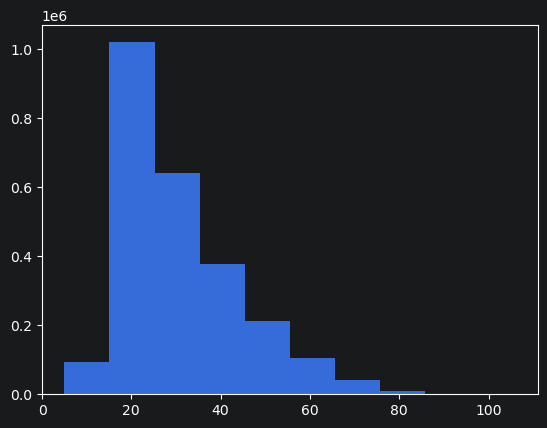

In [61]:
plt.hist(df['Age'])

Mode

$Mo = {Li + \left( {{\Delta_1} \over {\Delta_1 + \Delta_2}} \right) \cdot c}$

Mean

$\mu = {\sum x_i \over N}$

Variance

$\sigma^2 = {{\sum{(x_i - \mu)^2}} \over N}$

Standart Deviation


$\sigma = \sqrt{{{\sum{(x_i - \mu)^2}} \over N}}$


np.float64(17.68924277950953)

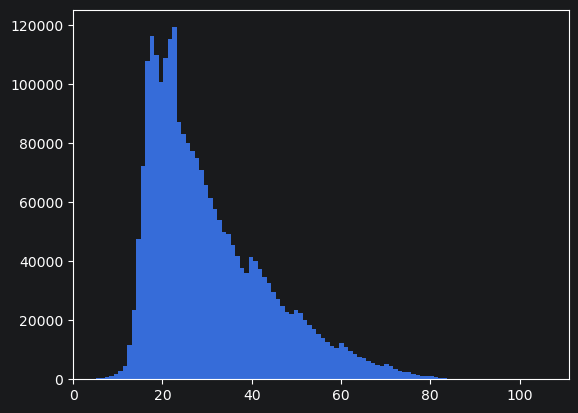

In [62]:
# Calculando usando a fórmula e o array do histograma
age_ax = plt.hist(df['Age'], bins=100)[:2]
height_bar = age_ax[0]
bar_values = age_ax[1]
idx_max = height_bar.argmax()

# Frequencias
li = height_bar.argmax()
c = bar_values[idx_max + 1] - li

# Altura das barras no histograma
bar_max_h = height_bar[idx_max]
bar_l = height_bar[idx_max - 1]
bar_r = height_bar[idx_max + 1]

# Deltas
d1 = bar_max_h - bar_l
d2 = bar_max_h - bar_r

# Substituindo na formula

mo = li + ( d1 / (d1+d2) ) * c

# mo = df.Age.value_counts().idxmax()
# ou df.Age.mode()[0]

df_mode = mo
df_mode

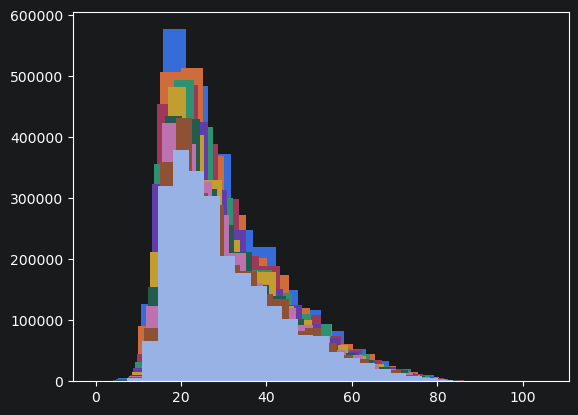

In [7]:
modes = []

for bin in range(20, 30):
    age_ax = plt.hist(df['Age'], bins=bin)[:2]
    height_bar = age_ax[0]
    bar_values = age_ax[1]
    idx_max = height_bar.argmax()

    li = height_bar.argmax()
    c = bar_values[idx_max + 1] - li

    bar_max_h = height_bar[idx_max]
    bar_l = height_bar[idx_max - 1]
    bar_r = height_bar[idx_max + 1]

    d1 = bar_max_h - bar_l
    d2 = bar_max_h - bar_r

    mo = li + ( d1 / (d1+d2) ) * c
    modes.append(mo)


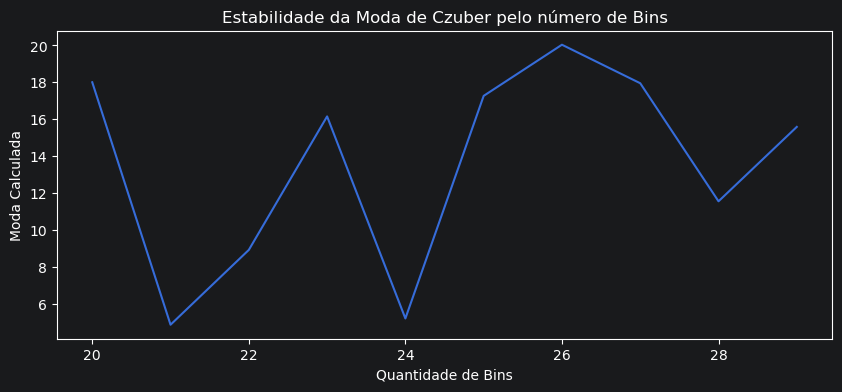

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(range(20, 30), modes)
plt.title("Estabilidade da Moda de Czuber pelo número de Bins")
plt.xlabel("Quantidade de Bins")
plt.ylabel("Moda Calculada")
plt.show()

Para sermos mais exatos na moda vamos arredondar todos o valores.

>Approximate ages occur because some federations only provide us with birth year information. So another way to think about approximate ages is that 23.5 implies that the lifter turns 24 that year.

Com base nisso vamos arredondar para cima.

In [125]:
df_age = df['Age'].sort_values(ascending=True)
df_age = df_age.reset_index(drop=True)
count_ages = df_age.count()
df_median = df_age[(count_ages - 1)/2]
df_median

np.int64(27)

In [15]:
df['Age'] = np.ceil(df['Age']).astype(int)

In [16]:
df_mode = df['Age'].mode()
df['Age'].value_counts().sort_values(ascending=False).head(5)

Age
23    119188
18    116068
22    115145
19    109924
21    108729
Name: count, dtype: int64

In [117]:
df_mean = sum(df.Age) / df.Age.count()
# ou df.Age.mean()
df_mean

np.float64(30.865022794247285)

In [12]:
# A soma de todos os valores menos a média dos valores sempre resulta em 0
# Como se fosse uma gangorra, quando ela está em 0º o resultado é 0
round(sum(df.Age - df.Age.mean()))

0

In [13]:
sum((df.Age - df.Age.mean())**2)

441085456.33827615

In [120]:
df_variance = sum((df.Age - df.Age.mean())**2) / df.Age.count()
df_variance

np.float64(176.21854347960704)

In [121]:
df_std_deviation = df_variance ** 0.5
df_std_deviation

np.float64(13.274733273388472)

Median:
$Me = 27$

Mode:
$Mo = 23$

Mean:
$\mu = 30.9$

Variance:
$\sigma^2 = 176.3$

Standart Deviation:
$\sigma = 13.3$


## Visualization


In [113]:
x = np.linspace(df['Age'].min(), df['Age'].max(), 200)
kde_f = gaussian_kde(df['Age'])
kde_v = kde_f(x)

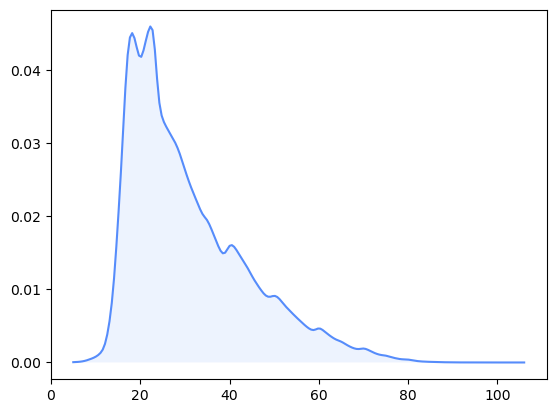

In [145]:
plt.plot(x, kde_v)
plt.fill_between(x, kde_v, alpha=0.1)

A melhor medida central que representa o conjunto de idades é a mediana.

* Metade dos powerlifters tem 27 anos ou menos, e a outra medade tem 27 anos ou mais.

Text(0.5, 1.0, 'Metade dos competidores tem 27 anos ou menos')

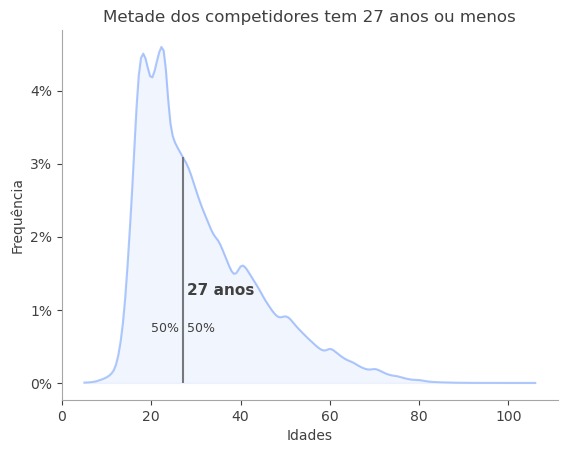

In [245]:
plt.plot(x, kde_v, alpha=0.45, color='C0')
plt.fill_between(x, kde_v, alpha=0.08, color='C0')

CINZA_ESCURO = '#414040'
plt.rcParams['text.color'] = CINZA_ESCURO
plt.rcParams['axes.labelcolor'] = CINZA_ESCURO
plt.rcParams['xtick.color'] = CINZA_ESCURO
plt.rcParams['ytick.color'] = CINZA_ESCURO
plt.rcParams['axes.edgecolor'] = CINZA_ESCURO

plt.vlines(x=df_median, ymin=0, ymax=kde_f(df_median)[0], colors='#76787B')
plt.text(df_median + 1, 0.012, "27 anos", color='#414040', fontsize=11, weight='semibold')
plt.text(df_median + 1, 0.007, "50%", color='#414040', fontsize=9)
plt.text(df_median - 7, 0.007, "50%", color='#414040', fontsize=9)

plt.yticks([0.00, 0.01, 0.02, 0.03, 0.04], ["0%", "1%", "2%", "3%", "4%"])

plt.xlabel("Idades")
plt.ylabel("Frequência")

plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().spines[['bottom', 'left']].set_color("#A6A6A5")

plt.title('Metade dos competidores tem 27 anos ou menos')

Text(0.5, 1.0, 'Mode Age')

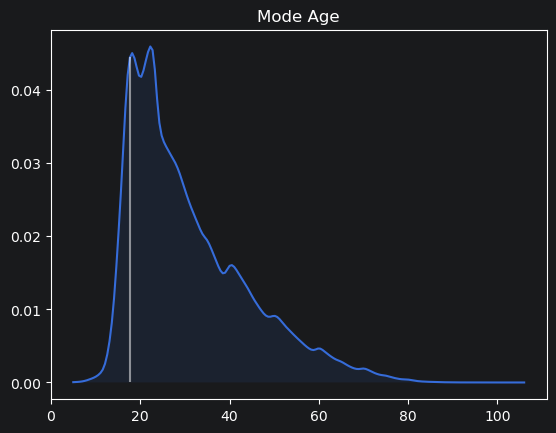

In [115]:
plt.plot(x, kde_v)
plt.fill_between(x, kde_v, alpha=0.1)

plt.vlines(x=df_mode, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.5)

plt.title('Mode Age')

A idade mais comum é 23 anos mas com 18, 19, 21 e 22 anos disputando com uma margem pequena.
O esporte tem uma concentração ampla de jovens entre 18 e 23 anos.

Text(0.5, 1.0, 'Mean Age')

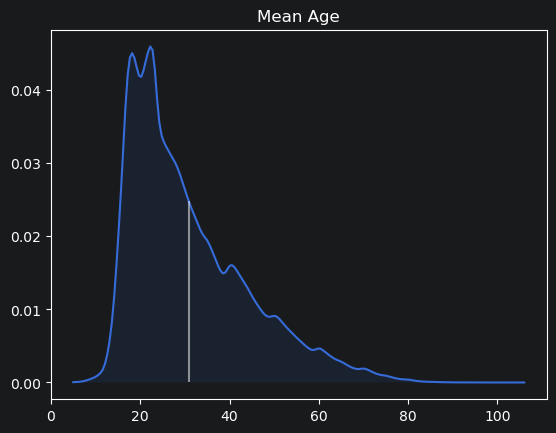

In [118]:
plt.plot(x, kde_v)
plt.fill_between(x, kde_v, alpha=0.1)

plt.vlines(x=df_mean, ymin=0, ymax=kde_f(df_mean)[0], colors='white', alpha=0.5)


plt.title('Mean Age')

Text(0.5, 1.0, 'Grid of Standard Deviation of Age')

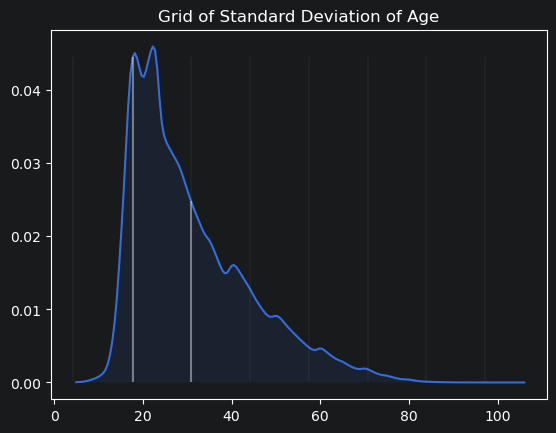

In [122]:
plt.plot(x, kde_v)
plt.fill_between(x, kde_v, alpha=0.1)

for i in range(6):
    plt.vlines(x=df_mean + df_std_deviation*i, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.03)

for i in range(1,3):
    plt.vlines(x=df_mean - df_std_deviation*i, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.03)

plt.vlines(x=df_mean, ymin=0, ymax=kde_f(df_mean)[0], colors='white', alpha=0.4)
plt.vlines(x=df_mode, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.4)

plt.title('Grid of Standard Deviation of Age')

Text(0.5, 1.0, 'Grid of Standard Deviation of Age')

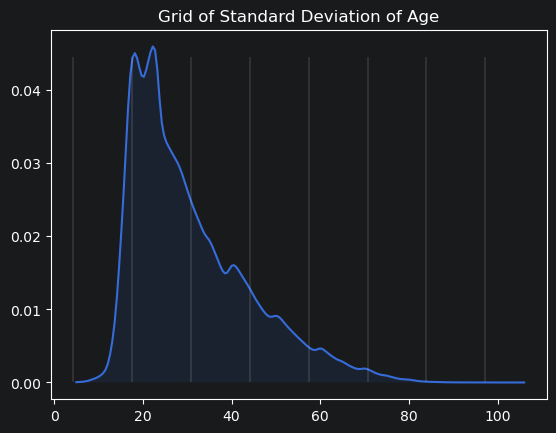

In [123]:
plt.plot(x, kde_v)
plt.fill_between(x, kde_v, alpha=0.1)

for i in range(6):
    plt.vlines(x=df_mean + df_std_deviation*i, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.1)

for i in range(1,3):
    plt.vlines(x=df_mean - df_std_deviation*i, ymin=0, ymax=kde_f(df_mode)[0], colors='white', alpha=0.1)


plt.title('Grid of Standard Deviation of Age')

Empirical Rule

$P(\mu - \sigma \le X \le \mu + \sigma) = {1 \over n}{\sum \mathbb{1} (\mu - \sigma \le x_i \le \mu + \sigma)}$

também conhecida como 68-95-99.7 rule

In [124]:
dentro = df[(df['Age'] >= df_mean - df_std_deviation) & (df['Age'] <= df_mean + df_std_deviation)]
percentual = len(dentro) / len(df) * 100
print(percentual)

73.07940026122532
